This is the README section for A0116298X's submission.

Contact: a0116298@u.nus.edu

### General Notes about this assignment 

**General Comments:**
* For the sake of convenient reading, every component for this Homework Assignment can be found in this IPython Notebook.

* All functions are created within the first few cells and have documentation via comments as well.

* Individual parts to the Programming Exercise are then answered in order of appearance.

* The answers for all the Essay Questions are found within this notebook, located after the Programming Exercises.

**Description of Architecture:**

* Load datasets code:
    * `load_data` is for loading the data in "hw1-train.dat" and "hw1-test.dat". Note that this function also adds in a dummy variable `1` to each instance, for the purpose of learnable bias.
* LR Code:
    * Here there is only one function, namely `lr` which does as required. 
    * Note that the `data` and `targets` arguments are only required to be numpy objects with "shape" attributes. In other words, `lr` will still work if `data` is a single instance and `target` is a `numpy.int32` for example (see the first two lines of implementation under `lr` for more details). I did this so that `lr` can perform both single-point and batch gradient descent.
* Evaluation Code:
    * `logistic_output` calculates the sigmoid "probabilities" inferred from logistic regression.
    * `classify_data` classifies the data into `+1` or `-1`.
    * `E_out` calculates $E_{out}(\mathbf{w})$, which is the total incorrect classifications divided by total test cases.
    * `E_in` calculates the Cross-Entropy Loss Measure $E_{in}(\mathbf{w})$ as defined in lecture.
* No plotting functions defined; the plots were done without any user-defined functions.
* Experiment results can be found below.

### Files included with this submission

No other files are included in this submission.


## Programming Exercise 1

In [1]:
import numpy as np
import numpy.random as nr
import matplotlib.pyplot as pl
%matplotlib inline
# Plotting with style! 
import seaborn as sb 

# Size the plot appropriately for online display
pl.rcParams['figure.figsize'] = (12.0, 10.0)

Let's fix the random number generator first, in case we need results that are replicable.

In [2]:
nr.seed(3244)

In [3]:
#    Write your solution to the programming assignment here.  We've suggested some cells that you can add 
#    to your notebook as single line comments below.
#    Please place all of your cells to be run in a linear, unintervened order, such that we can automate
#    the running and grading of the assignment.


# load datasets code
def load_data(filename):
    """
    Helper Function for Loading Datasets
        * filename : name of file with extension, e.g. 'hw1-train.dat'
    """
    f, X, Y = open(filename, 'rb'), [], []
    for line in f:
        entry = [float(i) for i in line.split()]
        X.append([1.] + entry[:-1]) # include bias term
        Y.append(entry[-1])
    X, Y = np.array(X).astype('float32'), np.array(Y).astype('int32')
    return X, Y


# LR code
def lr(data, targets, weights, eta=.05):
    """ 
    Logistic Regression Algorithm
    each function call invokes one update on the weight vector
        * data    : training dataset (features)
        * targets : corresponding targets
        * weights : vector of weight parameters
        * eta     : learning rate
    """
    data = data if len(data.shape) > 1 else [data]
    targets = targets if len(targets.shape) > 0 else [targets]
    gradient = lambda w, x, y: -(y * x) / (1 + np.exp(y * np.dot(w, x)))
    Gs = [gradient(weights, x, y) for x, y in zip(data, targets)]
    updates = np.zeros(len(weights))
    for gradient_vector in Gs:
        updates += gradient_vector
    updates /= np.float32(len(Gs))
    weights = weights - eta * updates
    return weights


# Evaluation code
def logistic_output(data, weights):
    """
    Calculates Logistic Regression Output (probabilities)
    i.e. returns a tuple (p, 1-p) where p = P(x == +1).
        * data   : dataset (each element is a vector of features)
        * weights: vector of weight parameters
    """        
    s = [np.dot(weights, d) for d in data]
    sigmoid = lambda x : np.exp(x) / (1. + np.exp(x))
    return zip(sigmoid(s), 1 - sigmoid(s))


def classify_data(data, weights):
    """
    Classifies Each Element in Dataset (+1 or -1)
        * data   : dataset (each element is a vector of features)
        * weights: vector of weight parameters
    """        
    probabilities = logistic_output(data, weights)
    sign = lambda P : 1 if P[0] > P[1] else -1
    prediction = [sign(P) for P in probabilities]
    return prediction


def E_out(data, targets, weights):
    """
    Calculates E_out (0/1 loss)
        * data    : test dataset (each element is a vector of features)
        * targets : corresponding targets
        * weights : vector of weight parameters
    """
    check_list = zip(classify_data(data, weights), targets)
    wrong = sum(1. for pred, actual in check_list if pred != actual)    
    return wrong / len(targets)


def E_in(data, targets, weights):
    """
    Calculates E_in (Cross-Entropy Error Measure)
        * data    : dataset (each element is a vector of features)
        * targets : corresponding targets
        * weights : vector of weight parameters
    """
    point_error = lambda w, x, y : np.log(1 + np.exp(-y * np.dot(w, x)))
    CE = np.mean([point_error(weights, x, y) for x, y in zip(data, targets)])
    return CE

#### Load Data

In [4]:
# setup data 
X_train, Y_train = load_data('hw1-train.dat')
X_test, Y_test = load_data('hw1-test.dat')
dim = len(X_train[0]) # dim = 20 + 1

#### Part (a): Run the algorithm with $\eta = 0.05$ and $T = 2333$. Output the eventual weight vector as $\mathbf{w}^{T}$ and $E_{out}$.

In [5]:
weights = np.zeros(dim)
for _ in range(2333):
    weights = lr(X_train, Y_train, weights, eta=0.05)
print(list(weights))
print(E_out(X_test, Y_test, weights))

[-0.11619989408431565, -0.6230638932034559, 0.83054699091665052, -1.0934973327817787, 0.055722735823371436, -1.113913880635466, -0.012965558072741232, 1.1124953339446455, -0.81588122432428911, 0.43092607867405358, 1.4234615455202937, 0.27688542997957105, -0.88095697492245106, -0.59741619562119086, 0.85704222994887858, 1.1536100752361806, 1.3039896611041255, -1.3480709994477067, 1.3424348693729125, -0.61636820289977645, -1.1006430605420776]
0.18433333333333332


#### Part (b): Run the algorithm with $\eta = 0.005$ and $T = 2333$. Output the eventual weight vector as $\mathbf{w}^{T}$ and $E_{out}$.

In [6]:
weights = np.zeros(dim)
for _ in range(2333):
    weights = lr(X_train, Y_train, weights, eta=0.005)
print(list(weights))
print(E_out(X_test, Y_test, weights))

[0.0068855508078635129, -0.11440970113830977, 0.17133392126178457, -0.2195381772745835, 0.031431981667107624, -0.23767226684820847, 0.018278466052511922, 0.2120912614951003, -0.1624184169171346, 0.087724934132706545, 0.31631168363751694, 0.058027318132944615, -0.15479095723674999, -0.096038347061514304, 0.19544843183975907, 0.25837087377476847, 0.27707535423927027, -0.29100914948394824, 0.27589159600311208, -0.12857103136474238, -0.23006944326485051]
0.26366666666666666


#### Part (c): Instead of using batch selection, use a deterministic version of gradient descent where we select and update weights on iterations based on a single point (like SGD), based on cycling through the data with restart, where $i = 1, 2, 3, 4, 5, .. N, 1, 2, \dots$. Output the eventual weight vector as a list $\mathbf{w}^{T}$ and $E_{out}$. For this part, re-run both the first two parts, a) and b).

In [7]:
# re-run of part (a)
weights = np.zeros(dim)
for i in range(2333):
    idx = i % len(X_train)
    weights = lr(X_train[idx], Y_train[idx], weights, eta=0.05)
print('Re-run of Part (a):')    
print(list(weights))
print(E_out(X_test, Y_test, weights))

# re-run of part (b)
weights = np.zeros(dim)
for i in range(2333):
    idx = i % len(X_train)
    weights = lr(X_train[idx], Y_train[idx], weights, eta=0.005)
print('\n\nRe-run of Part (b):')
print(list(weights))
print(E_out(X_test, Y_test, weights))

Re-run of Part (a):
[-0.13610500702634432, -0.71509139814152212, 0.87173523068486269, -1.1547142462943163, -0.045438353560166206, -1.1155966364007326, -0.056790365772758013, 1.0837057824363447, -0.92825164631685786, 0.42471630179643455, 1.4044058651677942, 0.17829298877650188, -0.79078276495856747, -0.69854612924682624, 0.85446604493845646, 1.1306861330012896, 1.2962021879737211, -1.4799120355384718, 1.4143478844671371, -0.66007026225852483, -1.0755394998748655]
0.22266666666666668


Re-run of Part (b):
[-0.0058756946027278632, -0.13261359160445849, 0.17183769816940175, -0.23245823671073618, -0.001289134047692677, -0.24747490714362366, 0.0045451936744939653, 0.20677977911415862, -0.17993032752856389, 0.084391294437810085, 0.30812906464387096, 0.034969577249976347, -0.14550272058986574, -0.10943276898760811, 0.18726770324385131, 0.24725378868592096, 0.26877878608000216, -0.31368319889501478, 0.27764022166942576, -0.13889373988655282, -0.22247116891900071]
0.19333333333333333


#### Part (d): Use the first two input dimensions and make a 2D plot of the data and separators at every 333th iteration. Start with a light line segment (20% gray; where 100% is black and 0% is white) for the first iteration and uniformly change the color to black as you reach the final Tth iteration. Do not worry about early convergence. This part is similar to the code in Tutorial 1. As the plot only shows two inputs of the twenty, it will not show any linear separation boundary.

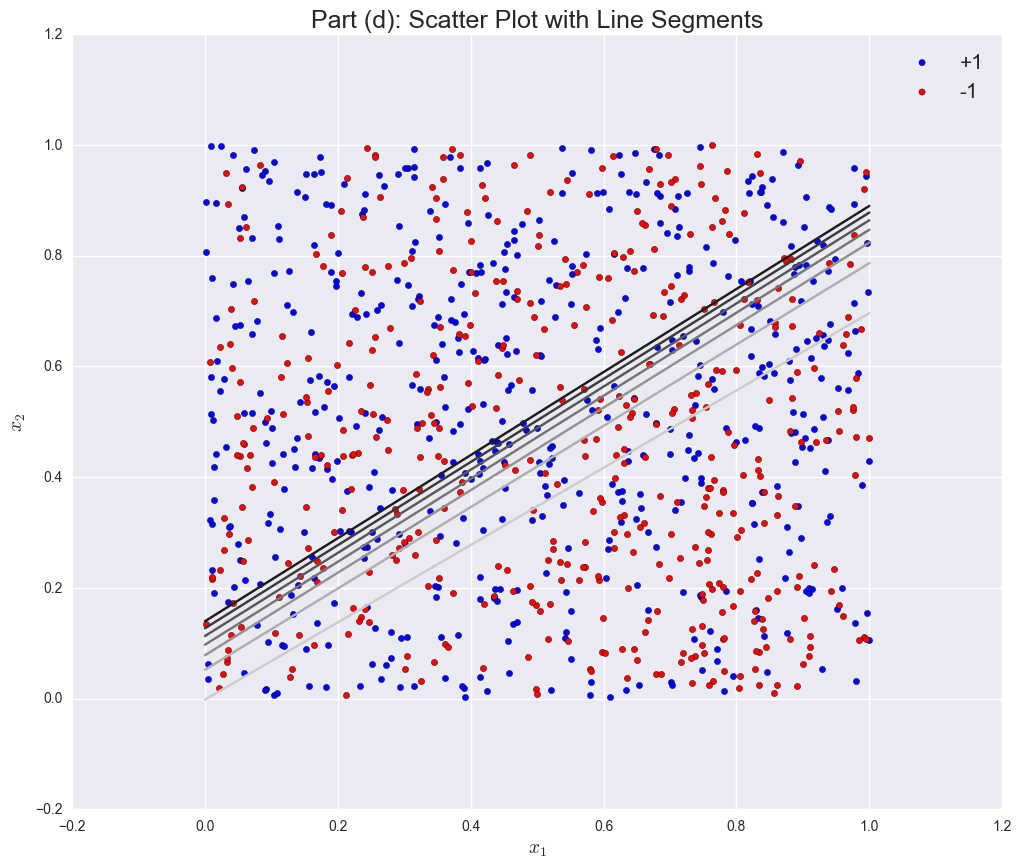

In [8]:
# for 2d scatter plot
x1_negatives = [x[1] for x, y in zip(X_train, Y_train) if y == -1]
x2_negatives = [x[2] for x, y in zip(X_train, Y_train) if y == -1]
x1_positives = [x[1] for x, y in zip(X_train, Y_train) if y == +1]
x2_positives = [x[2] for x, y in zip(X_train, Y_train) if y == +1]

# scatter plot of data
pl.scatter(x1_positives, x2_positives, c='blue')
pl.scatter(x1_negatives, x2_negatives, c='red')
pl.legend(['+1', '-1'], fontsize=15, loc='best')

# batch gradient descent with line segment visualization
weights = np.zeros(dim)
colour_intensity, delta = .80, .80/(2333./333.) # control shade of line seg.
for t in range(1,2334):
    weights = lr(X_train, Y_train, weights, eta=0.05)        
    if t % 333 == 0:
        x1 = np.linspace(0,1)
        x2 = (- weights[1] * x1 - weights[0]) / weights[2]
        pl.plot(x1, x2, c=str(colour_intensity))
        colour_intensity -= delta

pl.title('Part (d): Scatter Plot with Line Segments', size=18)
pl.xlabel(r'$x_{1}$', size=14)
pl.ylabel(r'$x_{2}$', size=14)

#### Part (e): Use the first two inputs variables and make a 3D plot of $E_{in}(\mathbf{w})$.
#### Part (f): Trace the progress of $\mathbf{w}$ towards its termination or convergence by plotting. Start with a light line segment (20% gray) for the first iteration and uniformly change the color to black as you reach the final $T$-th iteration. Do not worry about early convergence. This plot should be superimposed on Part (e), to make a plot similar to the ones shown in lecture.

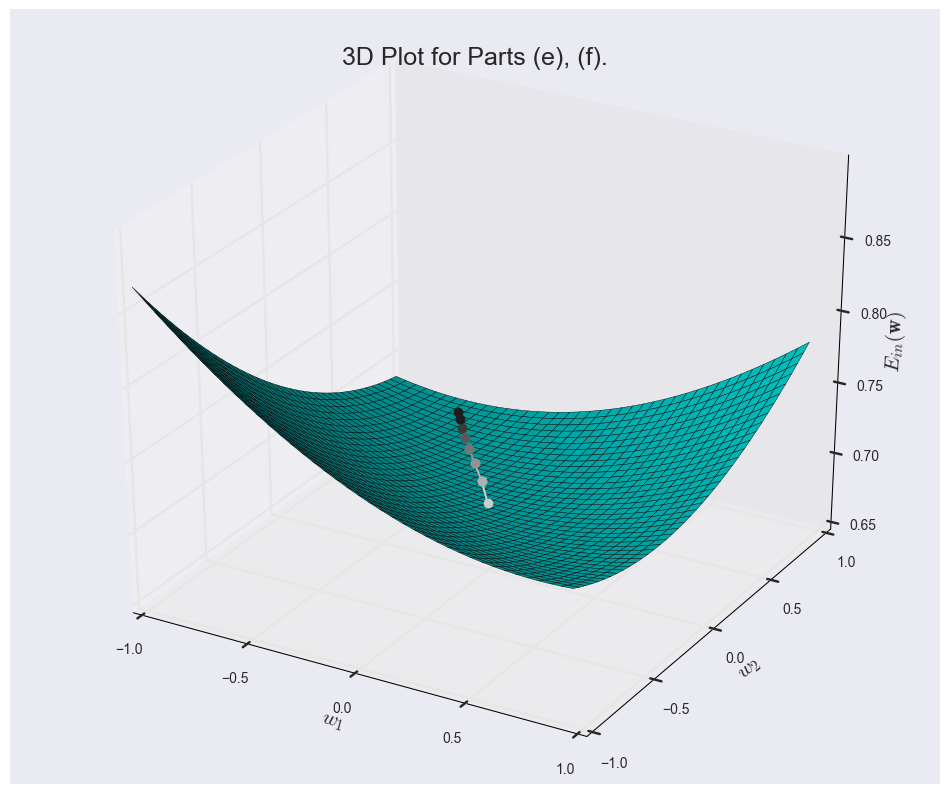

In [9]:
# code for part (e) + part (f)
from mpl_toolkits.mplot3d import Axes3D

# setup surface details
X_truncated = [x[1:3] for x in X_train]
W = np.arange(-1, 1, 0.05)
W1, W2 = np.meshgrid(W, W)
Z = np.zeros(W1.shape)
for i in range(W1.shape[0]):
    for j in range(W1.shape[1]):
        Z[i,j] = E_in(X_truncated, Y_train, [W1[i,j], W2[i,j]])

# 3D plot of E_in(w) as required in part (e)
fig = pl.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(W1, W2, Z, rstride=1, cstride=1, color='c')

# batch gradient descent with line segment visualization
weights = np.zeros(dim)
x1, y1, z1 = *weights[1:3], E_in(X_truncated, Y_train, weights[1:3])
colour_intensity, delta = .80, .80/(2333./333.) # control shade of line seg.
for t in range(1,2334):
    weights = lr(X_train, Y_train, weights, eta=0.05)        
    if t % 333 == 0:
        x2, y2, z2 = *weights[1:3], E_in(X_truncated, Y_train, weights[1:3])
        ax.plot([x1, x2], [y1, y2], [z1, z2], c=str(colour_intensity), marker='o', lw=1.5)
        x1, y1, z1 = x2, y2, z2
        colour_intensity -= delta

# plot details
ax.set_xlabel(r'$w_{1}$', size=15)
ax.set_ylabel(r'$w_{2}$', size=15)
ax.set_zlabel(r'$E_{in}(\mathbf{w})$', size=15)
pl.title('3D Plot for Parts (e), (f).', size=18)

## Statement of Individual Work

Please initial (between the square brackets) one of the following statements.

[ **M.N.** ] I, < **A0116298X** >, certify that I have followed the CS 3244 Machine Learning class guidelines for homework assignments.  In particular, I expressly vow that I have followed the Facebook rule in discussing with others in doing the assignment and did not take notes (digital or printed) from the discussions.  

[ ] I, <*substitute your matric number here*>, did not follow the class rules regarding the homework assignment, because of the following reason:

<*Please fill in*>

I suggest that I should be graded as follows:

<*Please fill in*>

### References

I have refered to the following list of people and websites in preparing my homework submission:

**[1] Yaser S. Abu-Mostafa, Malik Magdon-Ismail, and Hsuan-Tien Lin. 2012. Learning from Data. AMLBook.**

**[2] Matplotlib 3D Plot Tutorial: http://matplotlib.org/mpl_toolkits/mplot3d/tutorial.html **